# 10 · Benchmarking — Accuracy & Speed vs SG

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/10_benchmarking.ipynb)

How accurate and how fast is the surrogate relative to the SG oracle across many profiles? Surrogate inference is orders of magnitude faster, which is what makes gradient-based inverse design and UQ practical.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.12.0+cu130


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

import time
from bayespinn_inv.surrogate import (SymlogTransform, Normalizer, IVSurrogate,
    IVSurrogateConfig, build_sg_dataset, train_surrogate, SurrogateEnsemble)
symlog=SymlogTransform(I0=1e-6); biases=np.linspace(0.0,0.6,13)
profiles=[step(L) for L in np.geomspace(5e20,5e22,11)]
X,Y=build_sg_dataset(profiles,biases,scaling,sg,symlog); norm=Normalizer.fit(X)
net=IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR,hidden=128,n_layers=3,seed=0))
train_surrogate(net,X,Y,norm,epochs=2500,lr=2e-3); ens=SurrogateEnsemble([net],norm,symlog)


## Accuracy across held-out profiles + timing

median rel I-V err: 4.2%, p90: 10.8%


SG: 193.9 ms/curve   Surrogate: 0.4 ms/curve   speedup: 501×


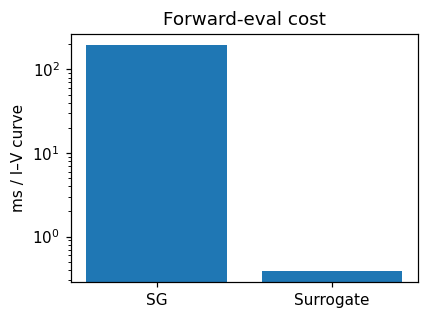

In [3]:

test=[step(L) for L in np.geomspace(7e20,4e22,8)]
rels=[]
for C in test:
    pred=ens.predict(scaling.doping_to_net_input(C), biases/VT); Isg=sg_iv(C,biases)
    for bi,V in enumerate(biases):
        if V>=0.1: rels.append(abs(pred.mean_current[bi]-Isg[bi])/abs(Isg[bi]))
rels=np.array(rels)
print(f"median rel I-V err: {np.median(rels):.1%}, p90: {np.quantile(rels,0.9):.1%}")

# timing: full I-V curve
t=time.time()
for _ in range(20): sg_iv(step(1e22), biases)
t_sg=(time.time()-t)/20
t=time.time()
for _ in range(20): ens.predict(scaling.doping_to_net_input(step(1e22)), biases/VT)
t_sur=(time.time()-t)/20
print(f"SG: {t_sg*1e3:.1f} ms/curve   Surrogate: {t_sur*1e3:.1f} ms/curve   speedup: {t_sg/t_sur:.0f}×")
plt.figure(figsize=(4,3))
plt.bar(["SG","Surrogate"],[t_sg*1e3,t_sur*1e3]); plt.ylabel("ms / I–V curve"); plt.yscale("log")
plt.title("Forward-eval cost"); plt.tight_layout(); plt.show()
